# PaySim Fraud — Exploratory Data Analysis

This notebook explores the PaySim mobile-money dataset to understand the fraud
signal before modelling. It runs on the **real** PaySim CSV
(`data/paysim.csv`, downloaded from Kaggle) when present, and otherwise falls
back to the project's synthetic generator, which reproduces the same schema and
fraud dynamics — so the notebook is always runnable.

**Questions we answer**
1. How imbalanced is fraud?
2. Which transaction types can be fraudulent?
3. How do amounts differ for fraud vs. legitimate transactions?
4. Do the balance-error features actually separate fraud?
5. What does this imply for feature engineering and modelling?

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [2]:
# Load the dataset (real PaySim if available, else generate synthetic).
DATA_PATH = Path("data/paysim.csv")
if not DATA_PATH.exists():
    print("data/paysim.csv not found — generating synthetic PaySim ...")
    from fraud_platform.data.generate_synthetic import generate

    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    generate(n_rows=200_000, seed=42).to_csv(DATA_PATH, index=False)

df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")
df.head()

data/paysim.csv not found — generating synthetic PaySim ...


Loaded 200,000 rows, 11 columns


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,CASH_OUT,2862.48,C158643361,8254.67,5392.19,C780270116,1246.37,4108.85,0,0
1,1,PAYMENT,3283.57,C247529684,4253.38,969.81,M606089504,0.00,0.00,0,0
2,1,CASH_OUT,865.67,C302114985,1212.90,347.23,C137787055,245.28,1110.95,0,0
3,1,PAYMENT,42.71,C765526717,26.60,0.00,M143284754,0.00,0.00,0,0
4,1,CASH_IN,35650.11,C294759433,51637.29,15987.18,C160125863,10830.28,46480.39,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            200000 non-null  int64  
 1   type            200000 non-null  str    
 2   amount          200000 non-null  float64
 3   nameOrig        200000 non-null  str    
 4   oldbalanceOrg   200000 non-null  float64
 5   newbalanceOrig  200000 non-null  float64
 6   nameDest        200000 non-null  str    
 7   oldbalanceDest  200000 non-null  float64
 8   newbalanceDest  200000 non-null  float64
 9   isFraud         200000 non-null  int64  
 10  isFlaggedFraud  200000 non-null  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 22.0 MB


## 1. Class imbalance

Fraud is rare — typically well under 1% of transactions. This is the central
challenge: naive accuracy is useless, so we care about **PR-AUC**, recall and
precision on the fraud class, and we weight the positive class during training.

In [4]:
fraud_rate = df["isFraud"].mean()
print(f"Fraud transactions: {int(df['isFraud'].sum()):,} / {len(df):,}")
print(f"Fraud rate: {fraud_rate:.4%}")
print(f"Imbalance ratio (legit:fraud): {int((1 - fraud_rate) / fraud_rate):,} : 1")

Fraud transactions: 260 / 200,000
Fraud rate: 0.1300%
Imbalance ratio (legit:fraud): 768 : 1


## 2. Fraud only occurs in TRANSFER and CASH_OUT

This is a defining property of PaySim: PAYMENT, CASH_IN and DEBIT are never
fraudulent. The platform encodes this as a hard rule — only TRANSFER / CASH_OUT
are scored by the model; everything else is scored 0.

          transactions  fraud_count  fraud_rate
type                                           
CASH_IN          44058            0    0.000000
CASH_OUT         69833          208    0.002979
DEBIT             1199            0    0.000000
PAYMENT          68043            0    0.000000
TRANSFER         16867           52    0.003083


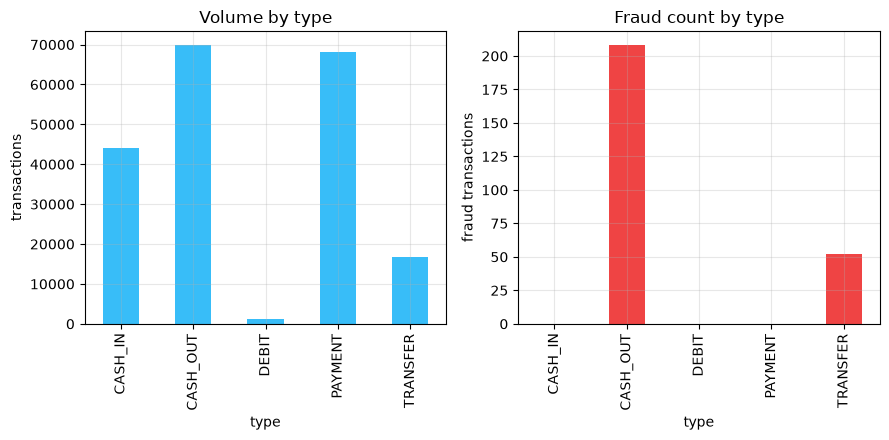

In [5]:
by_type = df.groupby("type")["isFraud"].agg(["count", "sum", "mean"])
by_type.columns = ["transactions", "fraud_count", "fraud_rate"]
print(by_type)

fig, axes = plt.subplots(1, 2)
by_type["transactions"].plot.bar(ax=axes[0], color="#38bdf8", title="Volume by type")
axes[0].set_ylabel("transactions")
by_type["fraud_count"].plot.bar(ax=axes[1], color="#ef4444", title="Fraud count by type")
axes[1].set_ylabel("fraud transactions")
plt.tight_layout()
plt.show()

## 3. Amount distribution: fraud vs. legitimate

Fraudulent transfers tend to move larger sums. Plotting on a log scale (amounts
are heavy-tailed) shows the fraud distribution shifted toward higher values.

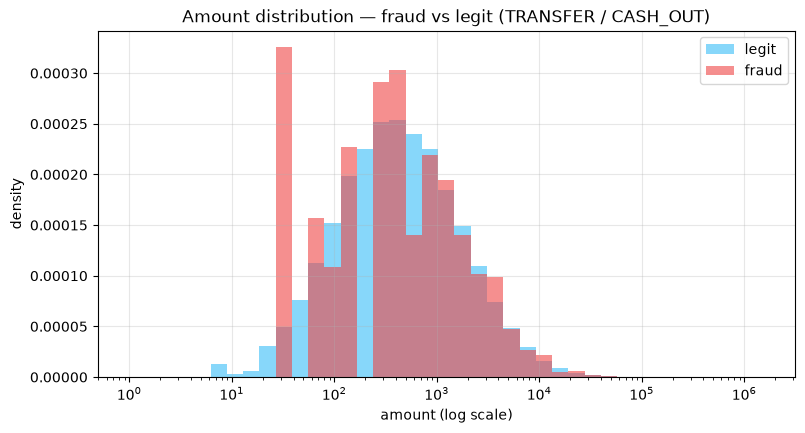

In [6]:
scored = df[df["type"].isin(["TRANSFER", "CASH_OUT"])].copy()
legit_amt = scored.loc[scored["isFraud"] == 0, "amount"].clip(lower=1)
fraud_amt = scored.loc[scored["isFraud"] == 1, "amount"].clip(lower=1)

import numpy as np

bins = np.logspace(0, np.log10(scored["amount"].max() + 1), 40)
plt.hist(legit_amt, bins=bins, alpha=0.6, label="legit", color="#38bdf8", density=True)
plt.hist(fraud_amt, bins=bins, alpha=0.6, label="fraud", color="#ef4444", density=True)
plt.xscale("log")
plt.xlabel("amount (log scale)")
plt.ylabel("density")
plt.title("Amount distribution — fraud vs legit (TRANSFER / CASH_OUT)")
plt.legend()
plt.show()

## 4. The balance-error features separate fraud

Genuine transactions obey accounting identities: the origin balance drops by
exactly the amount. Fraud breaks this. We define

* `errorBalanceOrig = newbalanceOrig + amount - oldbalanceOrg`
* `errorBalanceDest = oldbalanceDest + amount - newbalanceDest`

For legitimate transactions these are ~0; for fraud they are large. These are
the strongest signals the model uses.

Mean balance-error by class:
         errorBalanceOrig  errorBalanceDest
isFraud                                    
0              390.742618      3.076361e-15
1                0.000000      8.416186e+03


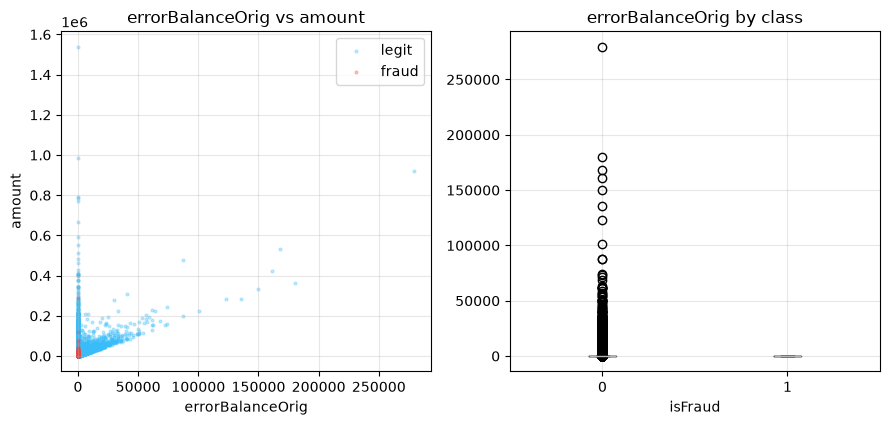

In [7]:
scored["errorBalanceOrig"] = (
    scored["newbalanceOrig"] + scored["amount"] - scored["oldbalanceOrg"]
)
scored["errorBalanceDest"] = (
    scored["oldbalanceDest"] + scored["amount"] - scored["newbalanceDest"]
)

summary = scored.groupby("isFraud")[["errorBalanceOrig", "errorBalanceDest"]].mean()
print("Mean balance-error by class:")
print(summary)

fig, axes = plt.subplots(1, 2)
for label, color in [(0, "#38bdf8"), (1, "#ef4444")]:
    sub = scored[scored["isFraud"] == label]
    axes[0].scatter(
        sub["errorBalanceOrig"], sub["amount"], s=4, alpha=0.3, color=color,
        label=("fraud" if label else "legit"),
    )
axes[0].set_xlabel("errorBalanceOrig")
axes[0].set_ylabel("amount")
axes[0].set_title("errorBalanceOrig vs amount")
axes[0].legend()

scored.boxplot(column="errorBalanceOrig", by="isFraud", ax=axes[1])
axes[1].set_title("errorBalanceOrig by class")
axes[1].set_xlabel("isFraud")
plt.suptitle("")
plt.tight_layout()
plt.show()

## 5. The "account drained" signature

A hallmark of fraud in PaySim: the origin account is emptied — `newbalanceOrig`
becomes 0 and the amount equals the old balance.

In [8]:
scored["orig_zeroed_out"] = ((scored["newbalanceOrig"] == 0) & (scored["amount"] > 0)).astype(int)
drained = scored.groupby("isFraud")["orig_zeroed_out"].mean()
print("Share of transactions that fully drain the origin account:")
print(f"  legit: {drained.get(0, 0):.2%}")
print(f"  fraud: {drained.get(1, 0):.2%}")

Share of transactions that fully drain the origin account:
  legit: 20.06%
  fraud: 100.00%


## 6. Feature correlation with fraud

A quick look at how the engineered features correlate with the fraud label —
balance-error terms and the drained-account flag dominate.

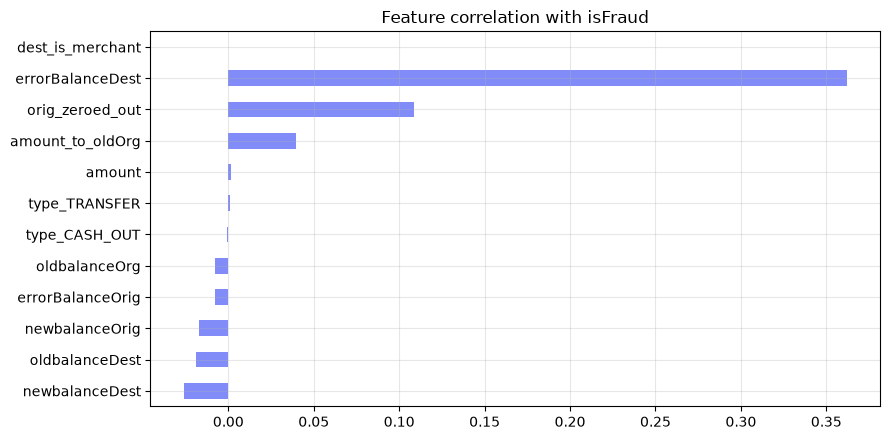

newbalanceDest     -0.026173
oldbalanceDest     -0.018839
newbalanceOrig     -0.017126
errorBalanceOrig   -0.008097
oldbalanceOrg      -0.008061
type_CASH_OUT      -0.000756
type_TRANSFER       0.000756
amount              0.001406
amount_to_oldOrg    0.039814
orig_zeroed_out     0.108686
errorBalanceDest    0.361995
dest_is_merchant         NaN
Name: isFraud, dtype: float64


In [9]:
from fraud_platform.features.engineering import build_features

feats = build_features(scored)
feats["isFraud"] = scored["isFraud"].values
corr = feats.corr()["isFraud"].drop("isFraud").sort_values()
corr.plot.barh(color="#818cf8", title="Feature correlation with isFraud")
plt.tight_layout()
plt.show()
print(corr)

## Takeaways for modelling

* **Extreme imbalance** → optimise/report PR-AUC, recall, precision; weight the
  positive class (`class_weight="balanced"` / `scale_pos_weight`).
* **Restrict to TRANSFER / CASH_OUT** — the only fraud-eligible types.
* **Balance-error features** (`errorBalanceOrig`, `errorBalanceDest`) and the
  **drained-account flag** carry most of the signal.
* The same `build_features` used here powers both training and real-time
  serving, guaranteeing no train/serve skew.